Instagram Data
Gavin Hockin
9/18/26
This data was captured by Meta and was downloaded by me.
This data was created with the purpose of keeping track of my Instagram activity through the years.
This data is reliable for the reason that it captures all activity since I created my account and comes directly from the source. It may be unreliable because the way data has been captured has been changed since I got my account, so there may be bugs or not up-to-date data. 

In [1]:
import json
import pandas as pd

with open('liked_posts.json', 'r') as f:
    data = json.load(f)

data[0]

{'timestamp': 1541805075,
 'media': [],
 'label_values': [{'label': 'URL',
   'value': 'https://www.instagram.com/p/Bp8JznshMdJ/',
   'href': 'https://www.instagram.com/p/Bp8JznshMdJ/'},
  {'label': 'Caption',
   'value': 'When the test results at the Doctors comes back negative...ð\x9f\x95ºð\x9f\x98³ð\x9f\x98\x82 @FamousAmos_SoFunny @IPodDadJ3X #WSHH'},
  {'label': 'Title', 'value': ''},
  {'dict': [{'dict': [{'label': 'Name', 'value': 'wshh'}], 'title': ''}],
   'title': 'Hashtags'},
  {'dict': [{'dict': [{'label': 'URL', 'value': 'https://linktr.ee/wshh'},
      {'label': 'Name', 'value': 'WorldStar Hip Hop / WSHH'},
      {'label': 'Username', 'value': 'worldstar'}],
     'title': ''}],
   'title': 'Owner'},
  {'dict': [], 'title': 'Brand partner'}],
 'fbid': '17867183728295581'}

In [2]:
row = {}
row['timestamp'] = data[0]['timestamp']

row

{'timestamp': 1541805075}

In [3]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']

row        

{'timestamp': 1541805075,
 'URL': 'https://www.instagram.com/p/Bp8JznshMdJ/',
 'Caption': 'When the test results at the Doctors comes back negative...ð\x9f\x95ºð\x9f\x98³ð\x9f\x98\x82 @FamousAmos_SoFunny @IPodDadJ3X #WSHH',
 'Title': ''}

In [4]:
for item in data[0]['label_values']:
    if 'label' in item:
        row[item['label']] = item['value']
    elif item.get('title') == 'Owner':
        owner_fields = item['dict'][0]['dict']
        for owner_item in owner_fields:
            row['Owner ' + owner_item['label']] = owner_item['value']
            
row

{'timestamp': 1541805075,
 'URL': 'https://www.instagram.com/p/Bp8JznshMdJ/',
 'Caption': 'When the test results at the Doctors comes back negative...ð\x9f\x95ºð\x9f\x98³ð\x9f\x98\x82 @FamousAmos_SoFunny @IPodDadJ3X #WSHH',
 'Title': '',
 'Owner URL': 'https://linktr.ee/wshh',
 'Owner Name': 'WorldStar Hip Hop / WSHH',
 'Owner Username': 'worldstar'}

In [5]:
tidy_rows= []

for entry in data:
    row = {}
    row['timestamp'] = entry['timestamp']

    for item in entry['label_values']:
        if 'label' in item:
            row[item['label']] = item['value']
        elif item.get('title') == 'Owner':
            owner_fields = item['dict'][0]['dict']
            for owner_item in owner_fields:
                row['Owner ' + owner_item['label']] = owner_item['value']
    tidy_rows.append(row)



In [6]:
likes_df = pd.DataFrame(tidy_rows)
likes_df.head(10)

,timestamp,URL,Caption,Title,Owner URL,Owner Name,Owner Username
0,1541805075,https://www.instagram.com/p/Bp8JznshMdJ/,When the test results at the Doctors comes bac...,,https://linktr.ee/wshh,WorldStar Hip Hop / WSHH,worldstar
1,1541805006,https://www.instagram.com/p/BpHpRT4jjCW/,Addictive Game for this week!,,,Words Story,words307
2,1541804865,https://www.instagram.com/p/Bp8QZEChRGx/,Itâs a WRAP for him ð¤£ @beendidit_,,,Overtime,overtime
3,1541804860,https://www.instagram.com/p/Bp77a_dgfcZ/,No Obstacle is Too Great! \n#YACkingð #TBT ...,,https://www.cameo.com/showtimetate,Golden Tate,showtimetate
4,1541804825,https://www.instagram.com/p/Bp-EdaIA12I/,#xxxtentacion has more albums to come as confi...,,https://linkin.bio/raptv,RapTV,rap
5,1541801836,https://www.instagram.com/p/Bp-cQJNHQHu/,You think my security hates me?,,http://sex9ine.com,,6ix9ine
6,1541800825,https://www.instagram.com/p/Bp-UAJPhw2y/,Trae getting taught the rookie way ð¿ð (v...,,https://stream.espn.com/,SportsCenter,sportscenter
7,1541800781,https://www.instagram.com/p/Bp-DMCmBOit/,Had to welcome LaMelo to Ohio ð® @melo (via ...,,,Overtime,overtime
8,1541800740,https://www.instagram.com/p/Bp4Z7L_Dwem/,The most addictive game!,,,Voodoo,runquiz
9,1541800711,https://www.instagram.com/p/Bp99fuWj6O0/,HOW HE DO THE 1X1 SO QUICK THOUGH... YOU BETTE...,,,One Shot Gaming,oneshotgamings


In [7]:
likes_df['DateTime'] = pd.to_datetime(likes_df['timestamp'], unit='s')
likes_df[['timestamp', 'DateTime']].head()

,timestamp,DateTime
0,1541805075,2018-11-09 23:11:15
1,1541805006,2018-11-09 23:10:06
2,1541804865,2018-11-09 23:07:45
3,1541804860,2018-11-09 23:07:40
4,1541804825,2018-11-09 23:07:05


In [8]:
likes_df.head(10)

,timestamp,URL,Caption,Title,Owner URL,Owner Name,Owner Username,DateTime
0,1541805075,https://www.instagram.com/p/Bp8JznshMdJ/,When the test results at the Doctors comes bac...,,https://linktr.ee/wshh,WorldStar Hip Hop / WSHH,worldstar,2018-11-09 23:11:15
1,1541805006,https://www.instagram.com/p/BpHpRT4jjCW/,Addictive Game for this week!,,,Words Story,words307,2018-11-09 23:10:06
2,1541804865,https://www.instagram.com/p/Bp8QZEChRGx/,Itâs a WRAP for him ð¤£ @beendidit_,,,Overtime,overtime,2018-11-09 23:07:45
3,1541804860,https://www.instagram.com/p/Bp77a_dgfcZ/,No Obstacle is Too Great! \n#YACkingð #TBT ...,,https://www.cameo.com/showtimetate,Golden Tate,showtimetate,2018-11-09 23:07:40
4,1541804825,https://www.instagram.com/p/Bp-EdaIA12I/,#xxxtentacion has more albums to come as confi...,,https://linkin.bio/raptv,RapTV,rap,2018-11-09 23:07:05
5,1541801836,https://www.instagram.com/p/Bp-cQJNHQHu/,You think my security hates me?,,http://sex9ine.com,,6ix9ine,2018-11-09 22:17:16
6,1541800825,https://www.instagram.com/p/Bp-UAJPhw2y/,Trae getting taught the rookie way ð¿ð (v...,,https://stream.espn.com/,SportsCenter,sportscenter,2018-11-09 22:00:25
7,1541800781,https://www.instagram.com/p/Bp-DMCmBOit/,Had to welcome LaMelo to Ohio ð® @melo (via ...,,,Overtime,overtime,2018-11-09 21:59:41
8,1541800740,https://www.instagram.com/p/Bp4Z7L_Dwem/,The most addictive game!,,,Voodoo,runquiz,2018-11-09 21:59:00
9,1541800711,https://www.instagram.com/p/Bp99fuWj6O0/,HOW HE DO THE 1X1 SO QUICK THOUGH... YOU BETTE...,,,One Shot Gaming,oneshotgamings,2018-11-09 21:58:31


In [9]:
likes_df.shape

(226924, 8)

In [10]:
likes_df['Owner Username'].isna().sum()

np.int64(0)

In [11]:
likes_df.dtypes

timestamp                 int64
URL                         str
Caption                     str
Title                       str
Owner URL                   str
Owner Name                  str
Owner Username              str
DateTime          datetime64[s]
dtype: object

In [12]:
likes_df.groupby("Owner Username")["DateTime"].count()

Owner Username
00exlle                1
00piumunderground    363
00piumuniversity       9
02deucee              10
05blur                 1
                    ... 
zyrtecallergy          1
zyshaunn               1
zzspongebobb           2
zzyzx_boii             1
zzzsrollingpapers      1
Name: DateTime, Length: 18527, dtype: int64

In [13]:
likes_by_account = (
    likes_df.groupby("Owner Username")["DateTime"]
    .count()
    .sort_values(ascending=False)
)
likes_by_account

Owner Username
sportscenter         8121
rap                  7468
nfl                  6430
espn                 5720
worldstar            4812
                     ... 
imahaterpodcast         1
imarkallin              1
imax.melbourne          1
imboggles               1
zzzsrollingpapers       1
Name: DateTime, Length: 18527, dtype: int64

My hypothesis is that a majority (more than 50%) of the posts I like was posted by an account that I currently follow (not an account I unfollowed, or never followed before but saw a post on reels or the discover page). 

In [14]:
import json
import pandas as pd

with open('following.json', 'r') as f:
    FollowingData = json.load(f)

This file will contain the accounts I follow, I can use it to compare the account names in the liked posts file.

In [15]:
FollowingData.keys()

dict_keys(['relationships_following'])

In [16]:
type(FollowingData["relationships_following"])

list

In [17]:
FollowingData["relationships_following"][0]

{'title': 'camramirez12',
 'string_list_data': [{'href': 'https://www.instagram.com/_u/camramirez12',
   'timestamp': 1787758643}]}

In [18]:
FollowingData["relationships_following"][0]["title"]

'camramirez12'

I pull the title out of the data in row 0 since it is the account name. I now have to make a DataFrame with my new file.

In [19]:
following_df = pd.DataFrame(FollowingData["relationships_following"])

following_df.head()

,title,string_list_data
0,camramirez12,[{'href': 'https://www.instagram.com/_u/camram...
1,clubchampionmedia,[{'href': 'https://www.instagram.com/_u/clubch...
2,tezzus,[{'href': 'https://www.instagram.com/_u/tezzus...
3,rough_rider_football,[{'href': 'https://www.instagram.com/_u/rough_...
4,hoopsview,[{'href': 'https://www.instagram.com/_u/hoopsv...


I want to count how many times a username from the "title" column in my following data fram matches a username in the "owner username" column in my liked posts data frame. To do this, I will use the isin() function.

When first looking at this data frame, I did not know whether to add more columns or keep it the same. I decided that I only needed what is shown because I can just count the "title" to find the accounts that match in the likes_df. 

In [21]:
match_count = likes_df['Owner Username'].isin(following_df['title']).sum()

print(match_count)

142155


To help me with this step, I had Claude explain the isin() function more to me so I can actually write the code myself with it still making sense to me.

I had 142,155 liked posts from accounts that I currently follow.

In [22]:
likes_df.shape

(226924, 8)

In the shape, it says there are 226,924 total rows. That means there are 226,924 posts that I have liked.

In [23]:
percentage = (142155 / 226924) * 100
print(f"{percentage:.2f}%")

62.64%


My hypothesis was correct, 62.64% of my liked posts have come from accounts I currently follow. 

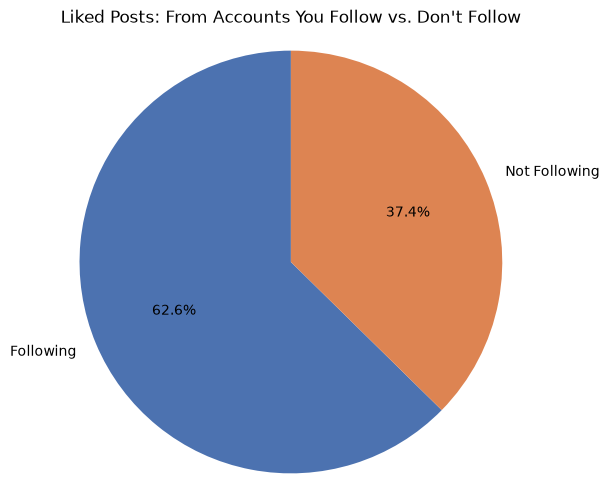

In [27]:
import matplotlib.pyplot as plt

match_count = likes_df['Owner Username'].isin(following_df['title']).sum()
non_match_count = len(likes_df) - match_count

labels = ['Following', 'Not Following']
counts = [match_count, non_match_count]
colors = ['#4C72B0', '#DD8452']

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Liked Posts: From Accounts You Follow vs. Don\'t Follow')
plt.axis('equal')
plt.show()

Here is a pie chart to show that majority of the posts I have liked come from an account I am currently folling.

I honestly did not know how to do this on my own, so again I used Claude to help me build a pie chart in Python 3. I wrote the match_count code and the non_match_count code but the rest of that code is from Claude. 